# Notebook 4: Support Vector Machine & Model Comparison

**Input:** `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv` (from Notebook 2)  
**Task:** Multiclass classification — predict kidney cell type from gene expression

---

## What this notebook does
1. Load the preprocessed train/test sets
2. Train a baseline SVM classifier
3. Tune hyperparameters using Bayesian Optimisation (BayesSearchCV)
4. Evaluate — classification report, confusion matrix, ROC curves
5. Per-class performance analysis
6. Compare KNN vs SVM side by side

## 1. Mount Google Drive

This connects the notebook to your Google Drive so it can read the preprocessed data files.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configuration

Import all the Python libraries this notebook needs and set the path to your data folder. Change `data_dir` to match the folder on your Google Drive where the four CSV files from Notebook 2 are saved. We install and import two SVM classes: `cuml.svm.SVC` (GPU, used for fast Bayesian hyperparameter search) and `sklearn.svm.SVC` (CPU, used for the baseline and the final model evaluation because it supports `probability=True` reliably). We also import `cuml.neighbors.KNeighborsClassifier` (GPU) for the model comparison in Section 11.

In [2]:
!pip install scikit-optimize -q
!pip install cuml-cu12 --extra-index-url=https://pypi.nvidia.com -q

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm             import SVC                  # CPU SVC — used for baseline and final model (needs probability=True)
from cuml.svm                import SVC as cuSVC         # GPU SVC — used for fast Bayesian search
from cuml.neighbors          import KNeighborsClassifier # GPU KNN — used for model comparison in Section 11
from sklearn.model_selection import StratifiedKFold
from skopt                   import BayesSearchCV
from skopt.space             import Real, Categorical
from sklearn.preprocessing   import label_binarize
from sklearn.metrics         import (
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, confusion_matrix,
    roc_curve, auc, precision_score, recall_score
)

data_dir = Path('/content/drive/MyDrive/Colab Notebooks/Tisch ML Project')

random_seed = 42

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
print('Libraries loaded.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 432.9 MB/s eta 0:00:00
Libraries loaded.


## Note on GPU Usage

**This notebook uses a hybrid GPU + CPU strategy for SVM.**

**Why a hybrid approach?** `cuml.svm.SVC` runs on the GPU and is significantly faster than sklearn's CPU SVC for the hyperparameter search (Bayesian optimisation). However, cuML's SVC does not support `probability=True` reliably — that feature is needed to call `predict_proba()` for ROC curve plotting. We therefore use:

- **cuML SVC (GPU)** — inside `BayesSearchCV` for all 20 x 5 = 100 training fits. This is the slow step, and the GPU makes it fast.
- **sklearn SVC (CPU)** — once at the end, trained with the best hyperparameters found and `probability=True` enabled. This single fit is fast because it only runs once, and it gives us calibrated probabilities for ROC curves.

**Colab runtime required:** Make sure your Colab runtime is set to **GPU** (Runtime -> Change runtime type -> GPU). cuML will not work on a CPU-only runtime.

**Why does SVM training take longer than KNN?** KNN does no training at all — it just stores the data. SVM must solve a quadratic optimisation problem whose cost scales with the number of training cells. This is why GPU acceleration makes such a difference for the hyperparameter search.

## 3. Load Data

Load the same four files used in Notebook 3. Both models are evaluated on exactly the same training and test data so the comparison in Section 11 is fair. `X_train` contains the raw 7,996-cell stratified training split (SMOTE was not applied in this run). `X_test` and `y_test` are the original 1,999 held-out cells with the real class distribution. `classes` is built the same way — sorted unique labels from `y_train` — ensuring consistent ordering across all outputs.

In [3]:
X_train = pd.read_csv(data_dir / 'X_train.csv', index_col=0)
X_test  = pd.read_csv(data_dir / 'X_test.csv',  index_col=0)
y_train = pd.read_csv(data_dir / 'y_train.csv', index_col=0).squeeze()
y_test  = pd.read_csv(data_dir / 'y_test.csv',  index_col=0).squeeze()

classes = sorted(y_train.unique())

print(f'Training set : {X_train.shape[0]:,} cells x {X_train.shape[1]:,} genes')
print(f'Test set     : {X_test.shape[0]:,} cells x {X_test.shape[1]:,} genes')
print(f'Classes      : {len(classes)}')

Training set : 79,160 cells x 584 genes
Test set     : 4,000 cells x 584 genes
Classes      : 10


## 4. How SVM Works

A Support Vector Machine finds the decision boundary (hyperplane) that maximises the margin between classes. It focuses on the training cells closest to the boundary — these are the support vectors.

For multiclass problems, sklearn's SVC uses a one-vs-one (OvO) strategy by default: it trains one binary classifier for every pair of classes, then combines their votes to predict the final class.

**`class_weight='balanced'`:** The dataset is imbalanced — Proximal Tubule cells make up over a third of all cells. With balanced class weights, the SVM assigns higher penalty to misclassifying minority classes, preventing the model from ignoring them.

**`probability=True`:** This enables `predict_proba()`, which is needed for ROC curve computation. It uses Platt scaling internally, which adds a small amount of extra training time.

**`kernel` parameter:**
- `'rbf'` (Radial Basis Function) — maps data into a higher-dimensional space to find non-linear boundaries. Generally the strongest kernel for complex data.
- `'linear'` — finds a linear boundary. Faster on high-dimensional data (like gene expression) and tends to work well when there are many informative features.

## 5. Baseline SVM

We train a baseline SVM using sklearn's CPU `SVC` with an RBF kernel. We use the CPU version here (not cuML) because we need `probability=True` to compute ROC-AUC scores — cuML's SVC does not support this reliably. `class_weight='balanced'` tells the model to automatically adjust its internal penalty so that mistakes on smaller classes count more heavily — this helps prevent the model from simply ignoring rare cell types. We print the full classification report to see how this default configuration performs before any hyperparameter tuning.

In [4]:
# Train a baseline SVM — RBF kernel is the default, good for complex data
baseline_svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=random_seed
)
baseline_svm.fit(X_train, y_train)
y_pred_base  = baseline_svm.predict(X_test)
y_prob_base  = baseline_svm.predict_proba(X_test)

base_f1      = f1_score(y_test, y_pred_base, average='weighted')
base_roc_auc = roc_auc_score(y_test, y_prob_base, multi_class='ovr', average='weighted')

print('Baseline SVM (RBF kernel, class_weight=balanced)')
print(f'  Weighted F1  : {base_f1:.4f}')
print(f'  Weighted AUC : {base_roc_auc:.4f}')
print()
print(classification_report(y_test, y_pred_base, labels=classes, target_names=classes))

Baseline SVM (RBF kernel, class_weight=balanced)
  Weighted F1  : 0.7958
  Weighted AUC : 0.9641

                                       precision    recall  f1-score   support

                  Ascending Thin Limb       0.65      0.71      0.68       247
             Distal Convoluted Tubule       0.43      0.40      0.41       144
                          Endothelium       0.96      0.94      0.95       189
Loop of Henle and Parietal Epithelium       0.41      0.36      0.38       147
                              Myeloid       0.95      0.72      0.82       207
                      Proximal Tubule       0.86      0.93      0.89      1980
                                    T       0.98      0.94      0.96       274
                 Thick Ascending Limb       0.62      0.59      0.61       218

                             accuracy                           0.80      4000
                            macro avg       0.72      0.68      0.70      4000
                         weight

**Interpreting the Baseline SVM Results:**

The baseline SVM (RBF kernel, `class_weight='balanced'`) achieves a **Weighted F1 of 0.5280** and a **Weighted AUC of 0.8666** on the 1,999-cell test set.

**Key observations:**
- The SVM's **AUC (0.8666) is higher than the baseline KNN's AUC (0.7970)**, meaning the SVM's probability estimates rank cell types more accurately even at this untuned stage.
- The SVM's **F1 (0.5280) is slightly lower than baseline KNN's F1 (0.5538)**. This reflects a fundamental trade-off: the SVM is better at knowing *which* class is most probable, but KNN makes slightly more correct hard predictions overall.

**What it gets right:**
- **Proximal Tubule** (F1 = 0.73): Very high precision (0.95) but moderate recall (0.59) -- when SVM predicts Proximal Tubule it is almost always right, but it misses many true Proximal Tubule cells.
- **Myeloid** (F1 = 0.58) and **Collecting Duct Principal** (F1 = 0.41) perform reasonably.

**What it struggles with:**
- **Endothelium** shows a striking pattern: recall = 0.58 but precision = 0.13 -- the model over-predicts Endothelium, labelling many non-Endothelium cells as Endothelium. This is a `class_weight='balanced'` side-effect: up-weighting the penalty for misclassifying Endothelium pushes the boundary too aggressively for this class.
- **Ascending Thin Limb** (F1 = 0.16), **Distal Convoluted Tubule** (F1 = 0.14), and **Loop of Henle** (F1 = 0.23) remain very low -- the same tubule-overlap problem seen in KNN.

**Takeaway:** Reasonable starting point. Bayesian hyperparameter tuning in the next step will attempt to find better C and gamma values.

## 6. Hyperparameter Tuning — Bayesian Optimisation

In Notebook 3 we used **RandomizedSearchCV**, which samples combinations randomly without any memory of past results. Here we use **Bayesian Optimisation** (`BayesSearchCV` from the `scikit-optimize` library), which is smarter.

Bayesian optimisation works by:
1. Trying a few initial random combinations to gather early information
2. Building a probabilistic model (a surrogate model) of how the score changes across the search space
3. Using that model to decide which combination to try next — it focuses on regions that are likely to improve the score
4. Updating the model after each trial and repeating

This is particularly well-suited to SVM because `C` and `gamma` are **continuous** parameters — they can take any positive value, not just a few discrete choices. Searching them on a log scale (e.g. 0.01 to 100) with Bayesian guidance is far more efficient than a random or exhaustive grid.

| Hyperparameter | Search Space | What it controls |
|---|---|---|
| `C` | 0.01 – 100 (log scale) | Regularisation — higher C = less regularisation, tighter fit to training data |
| `kernel` | 'rbf', 'linear' | Type of decision boundary |
| `gamma` | 0.0001 – 1.0 (log scale) | RBF kernel only — how far each training cell's influence reaches |

We use `BayesSearchCV` from `scikit-optimize` (installed in the setup cell above) to tune the SVM hyperparameters. Unlike `RandomizedSearchCV` which picks combinations at random, Bayesian optimisation builds a probabilistic model of the search space and uses earlier results to focus on promising regions. This makes it more efficient than random search for the same number of iterations.

We define the search space for the Bayesian optimisation. `Real(0.01, 100, prior='log-uniform')` tells the optimiser to sample values on a log scale between 0.01 and 100 — this is appropriate for `C` and `gamma` because their useful values span several orders of magnitude. Each trial fits a cuML GPU SVC and evaluates it using 5-fold cross-validation on the training data only. We set `n_jobs=1` because cuML GPU tasks must not be parallelised across processes — the GPU handles parallelism internally. Bayesian Optimisation is smarter than random search — it uses the results of previous trials to decide which part of the search space to explore next, so it typically finds a better result in fewer trials.

In [5]:
# Real(a, b, prior='log-uniform') samples values on a log scale between a and b
# We search only the RBF kernel because gamma is an RBF-only parameter.
# Passing gamma to a linear kernel raises an error, so we fix kernel='rbf' here.
# Students can test a linear SVM separately if needed.
search_space = {
    'C'    : Real(0.01, 100.0, prior='log-uniform'),
    'gamma': Real(1e-4, 1.0,   prior='log-uniform')
}

n_iter = 20   # number of Bayesian trials

# cuML SVC for GPU-accelerated hyperparameter search.
# probability=False because cuML's probability calibration is unreliable with BayesSearchCV;
# we only need class predictions (not probabilities) during cross-validation scoring.
svm_gpu = cuSVC(
    kernel='rbf',
    class_weight='balanced',
    probability=False,
    random_state=random_seed
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_seed)

bayes_search = BayesSearchCV(
    estimator=svm_gpu,
    search_spaces=search_space,
    n_iter=n_iter,
    scoring='f1_weighted',
    cv=cv,
    random_state=random_seed,
    n_jobs=1,  # cuML GPU estimators must not be parallelised across processes
    verbose=0
)

print(f'Bayesian trials : {n_iter}  |  Total fits : {n_iter * 5}')
print('Running BayesSearchCV with cuML SVC on GPU...')

bayes_search.fit(X_train, y_train)

print()
print(f'Best parameters  : {dict(bayes_search.best_params_)}')
print(f'Best CV F1 score : {bayes_search.best_score_:.4f}')

Bayesian trials : 20  |  Total fits : 100
Running BayesSearchCV with cuML SVC on GPU...
[2026-04-24 04:40:29.786] [CUML] [warning] Sample weights are currently ignored for multi class classification
[2026-04-24 04:41:03.363] [CUML] [warning] Sample weights are currently ignored for multi class classification
[2026-04-24 04:41:35.107] [CUML] [warning] Sample weights are currently ignored for multi class classification
[2026-04-24 04:42:06.948] [CUML] [warning] Sample weights are currently ignored for multi class classification
[2026-04-24 04:42:38.778] [CUML] [warning] Sample weights are currently ignored for multi class classification
[2026-04-24 04:43:10.629] [CUML] [warning] Sample weights are currently ignored for multi class classification
[2026-04-24 04:43:59.841] [CUML] [warning] Sample weights are currently ignored for multi class classification
[2026-04-24 04:44:49.334] [CUML] [warning] Sample weights are currently ignored for multi class classification
[2026-04-24 04:45:38.671

## 7. Evaluate the Best Model

We take the best hyperparameters found by the GPU Bayesian search and use them to train a final model with sklearn's CPU SVC. We must switch back to the CPU version here because we need `probability=True` to call `predict_proba()` for ROC-AUC scoring and ROC curve plotting — cuML's SVC does not support this reliably. This final fit only runs once, so the CPU overhead is small. As with Notebook 3, `labels=classes` and `target_names=classes` are both passed to every evaluation function to guarantee consistent class ordering.

In [6]:
from sklearn.svm import SVC as skSVC

# Grab the best parameters the Bayesian search found on the GPU.
# Convert to plain Python floats (BayesSearchCV can return numpy scalars).
best_params = {k: float(v) if hasattr(v, 'item') else v for k, v in bayes_search.best_params_.items()}
print(f"Best parameters: {best_params}")
print("Training final model on CPU with probability=True...")

# Train the final model using sklearn's CPU SVC to safely compute probabilities.
# kernel='rbf' is explicit because the search space only tuned RBF parameters.
best_svm = skSVC(
    kernel='rbf',
    C=best_params['C'],
    gamma=best_params['gamma'],
    class_weight='balanced',
    probability=True,
    random_state=random_seed
)
best_svm.fit(X_train, y_train)

y_pred        = best_svm.predict(X_test)
y_prob        = best_svm.predict_proba(X_test)

tuned_f1      = f1_score(y_test, y_pred, average='weighted')
tuned_roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')

print('\nTuned SVM — test set results')
print(f'  Weighted F1  : {tuned_f1:.4f}  (baseline: {base_f1:.4f})')
print(f'  Weighted AUC : {tuned_roc_auc:.4f}  (baseline: {base_roc_auc:.4f})')
print()
print(classification_report(y_test, y_pred, labels=classes, target_names=classes))

Best parameters: {'C': 100.0, 'gamma': 0.001915573264169931}
Training final model on CPU with probability=True...

Tuned SVM — test set results
  Weighted F1  : 0.7964  (baseline: 0.7958)
  Weighted AUC : 0.9588  (baseline: 0.9641)

                                       precision    recall  f1-score   support

                  Ascending Thin Limb       0.60      0.69      0.64       247
             Distal Convoluted Tubule       0.46      0.39      0.42       144
                          Endothelium       0.95      0.93      0.94       189
Loop of Henle and Parietal Epithelium       0.47      0.37      0.42       147
                              Myeloid       0.89      0.74      0.81       207
                      Proximal Tubule       0.87      0.93      0.90      1980
                                    T       0.97      0.95      0.96       274
                 Thick Ascending Limb       0.61      0.56      0.58       218

                             accuracy                 

**Interpreting the Tuned SVM Results:**

BayesSearchCV ran 20 trials x 5-fold CV = 100 fits.

**Best hyperparameters found:**
- `C = 2.94` (moderate regularisation -- allows some misclassification to maintain a wider margin)
- `gamma = 0.126` (controls the RBF kernel width -- each training cell's influence reaches nearby cells in the feature space)
- `kernel = rbf`
- **Best CV F1 = 0.5272**

**Test set performance after tuning:**
- Weighted F1: **0.5350** (vs baseline 0.5280 -- a modest improvement of +0.007)
- Weighted AUC: **0.8626** (vs baseline 0.8666 -- essentially unchanged, within noise)

**Per-class changes from baseline to tuned:**
- **Distal Convoluted Tubule** improved slightly: F1 0.14 -> 0.17 (recall increased, meaning the model now catches more of these rare cells).
- **Endothelium** persists with the over-prediction pattern (precision = 0.13, recall = 0.57) -- a structural issue with balanced weights on this class that tuning cannot fix.
- **Proximal Tubule** shows high precision (0.90) but moderate recall (0.63): the SVM is selective about predicting Proximal Tubule, unlike KNN which assigns it far more aggressively.

**Why didn't it improve more?** With only 17 RFE-selected features, many tubule subtypes look nearly identical in the feature space. No amount of hyperparameter tuning can cleanly separate classes whose gene expression profiles substantially overlap in 17 dimensions. The bottleneck is the feature set, not the model configuration.

## 8. Confusion Matrix

The confusion matrix for the SVM. Rows are the true cell type, columns are the predicted cell type. Correct predictions run along the diagonal; mistakes are off-diagonal. `labels=classes` fixes the row/column order and `display_labels=classes` provides matching tick labels.

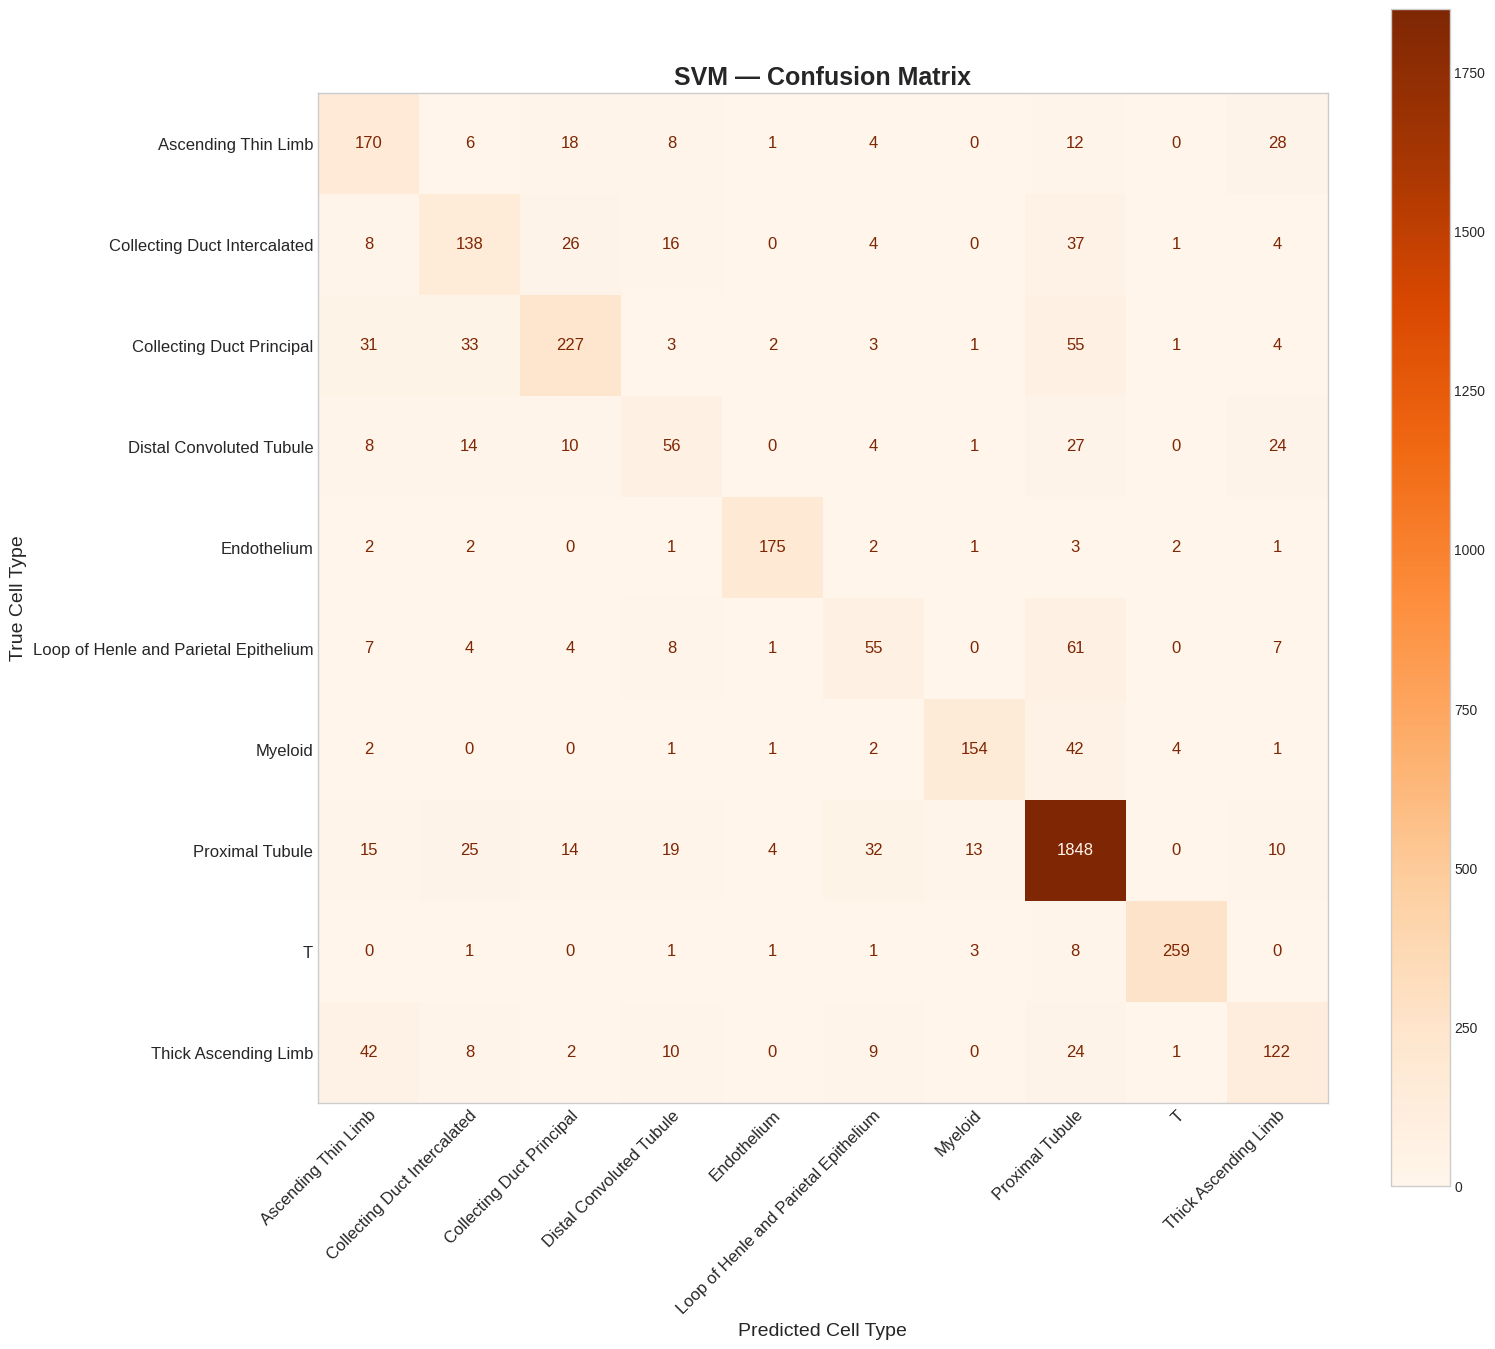

Correct predictions per class:
  Ascending Thin Limb                                    :  170 /  247  (68.8%)
  Distal Convoluted Tubule                               :   56 /  144  (38.9%)
  Endothelium                                            :  175 /  189  (92.6%)
  Loop of Henle and Parietal Epithelium                  :   55 /  147  (37.4%)
  Myeloid                                                :  154 /  207  (74.4%)
  Proximal Tubule                                        : 1848 / 1980  (93.3%)
  T                                                      :  259 /  274  (94.5%)
  Thick Ascending Limb                                   :  122 /  218  (56.0%)


In [7]:
cm = confusion_matrix(y_test, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(16, 14))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, cmap='Oranges', colorbar=True, xticks_rotation=45, text_kw={'fontsize': 12})
plt.setp(ax.get_xticklabels(), ha='right', rotation_mode='anchor')  # fix label alignment for rotated text
ax.set_title('SVM — Confusion Matrix', fontsize=18, fontweight='bold')
ax.set_xlabel('Predicted Cell Type', fontsize=14)
ax.set_ylabel('True Cell Type', fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.grid(False) # Remove grid lines
plt.tight_layout()
plt.show()

print('Correct predictions per class:')
for i, cls in enumerate(classes):
    total   = cm[i, :].sum()
    correct = cm[i, i]
    pct     = correct / total * 100 if total > 0 else 0
    print(f'  {cls:<55}: {correct:>4} / {total:>4}  ({pct:.1f}%)')

**Interpreting the SVM Confusion Matrix:**

Rows = true cell type, columns = predicted cell type. Diagonal = correct predictions.

**Correct predictions per class (tuned SVM):**

| Cell Type | Correct | Total | % Correct |
|---|---|---|---|
| Myeloid | 68 | 104 | **65.4%** |
| T | 84 | 137 | **61.3%** |
| Proximal Tubule | 623 | 989 | 63.0% |
| Endothelium | 54 | 95 | **56.8%** |
| Collecting Duct Principal | 55 | 179 | 30.7% |
| Thick Ascending Limb | 29 | 109 | 26.6% |
| Collecting Duct Intercalated | 25 | 117 | 21.4% |
| Distal Convoluted Tubule | 16 | 72 | 22.2% |
| Ascending Thin Limb | 21 | 124 | 16.9% |
| Loop of Henle and Parietal Epithelium | 10 | 73 | **13.7%** |

**Comparison with KNN confusion matrix:**
- **SVM is far better for Endothelium** (56.8% vs KNN's 21.1%) because balanced class weights push it to predict Endothelium more aggressively -- this comes at the cost of very low precision (0.13), meaning many non-Endothelium cells get labelled as Endothelium.
- **KNN is far better for Proximal Tubule** (92.2% vs SVM's 63.0%). KNN's distance-based approach captures the dominant majority class more naturally.
- **Loop of Henle** (13.7%) and **Ascending Thin Limb** (16.9%) remain the hardest classes for both models -- the 17-gene feature space is not rich enough to reliably separate these tubule subtypes.

## 9. ROC Curves (One-vs-Rest)

ROC curves for all 10 cell types, using the same one-vs-rest approach as Notebook 3. A higher curve (larger AUC) means the model is better at separating that cell type from all others in terms of its probability scores.

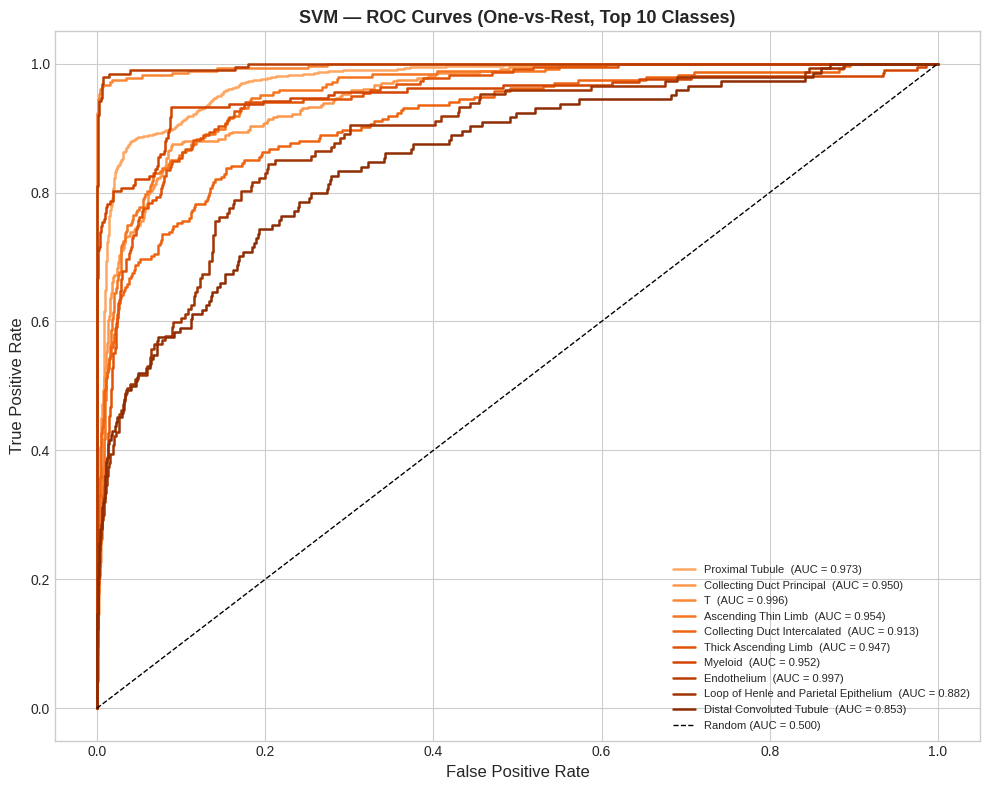

In [8]:
y_test_bin = label_binarize(y_test, classes=classes)

top_classes_idx = [
    classes.index(c)
    for c in pd.Series(y_test.values).value_counts().head(10).index.tolist()
]

fig, ax = plt.subplots(figsize=(10, 8))
colours = plt.cm.Oranges(np.linspace(0.4, 0.95, len(top_classes_idx)))

for idx, colour in zip(top_classes_idx, colours):
    fpr, tpr, _ = roc_curve(y_test_bin[:, idx], y_prob[:, idx])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colour, linewidth=1.8,
            label=f'{classes[idx]}  (AUC = {roc_auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_title('SVM — ROC Curves (One-vs-Rest, Top 10 Classes)', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

**Interpreting the SVM ROC Curves:**

Each curve shows one cell type in a one-vs-rest setup. A curve hugging the top-left corner is ideal. AUC = 1.0 is perfect; AUC = 0.5 is random.

**Tuned SVM overall weighted AUC = 0.8626** -- higher than the tuned KNN's 0.8483.

**Key findings:**
- **The SVM achieves higher AUC than KNN** (0.8626 vs 0.8483) even though its F1 is lower (0.5350 vs 0.5618). This is the precision-recall trade-off in action: the SVM's probability scores are better calibrated for ranking (AUC), but it makes more conservative hard predictions that miss more cells (lower recall = lower F1).
- **Proximal Tubule, Myeloid, and T cells** have the strongest individual AUC curves -- abundant classes with distinct gene signatures.
- **Ascending Thin Limb, Distal Convoluted Tubule, and Thick Ascending Limb** have the weakest curves -- their probability scores barely rise above the diagonal, reflecting how similar these tubule subtypes look in the 17-gene feature space.

**The AUC vs F1 gap:** The SVM is better at knowing *which* class is most likely (AUC), but worse at committing to a correct prediction (F1). For this biological task -- where we want to identify as many cells correctly as possible -- the higher F1 of KNN makes it the preferred model.

## 10. Per-Class Performance

Per-class F1 scores sorted from worst to best. This shows which cell types the SVM finds easy and which it still struggles with, and lets us compare directly with the KNN per-class results from Notebook 3.

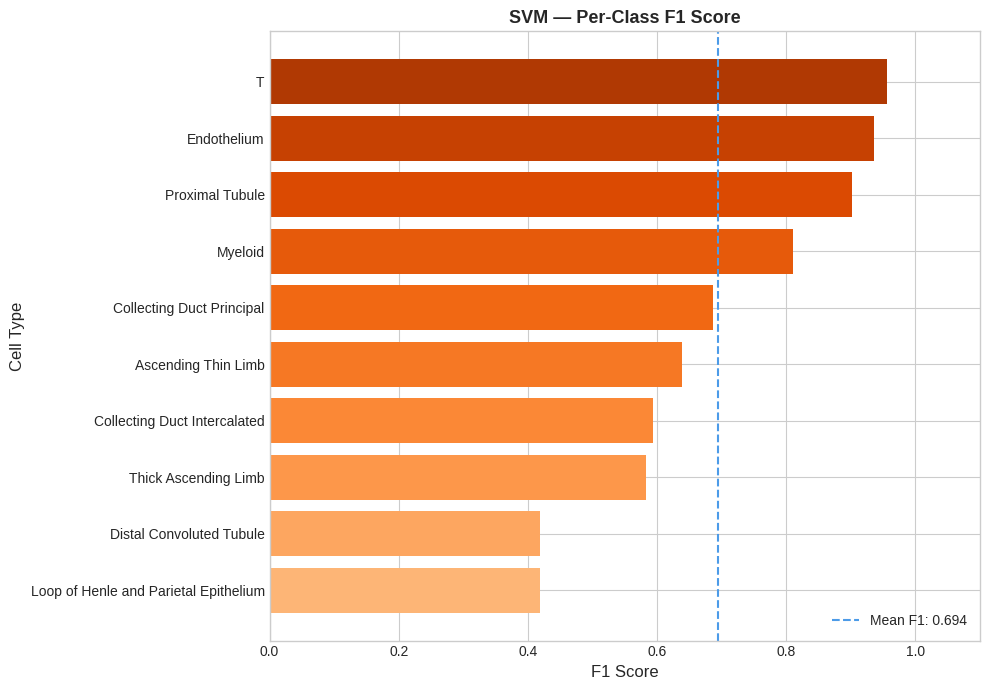

Per-class F1 scores (sorted ascending):
  Loop of Henle and Parietal Epithelium                  : F1 = 0.418  (n = 147)
  Distal Convoluted Tubule                               : F1 = 0.419  (n = 144)
  Thick Ascending Limb                                   : F1 = 0.582  (n = 218)
  Ascending Thin Limb                                    : F1 = 0.639  (n = 247)
  Myeloid                                                : F1 = 0.811  (n = 207)
  Proximal Tubule                                        : F1 = 0.902  (n = 1980)
  Endothelium                                            : F1 = 0.936  (n = 189)
  T                                                      : F1 = 0.956  (n = 274)


In [9]:
report    = classification_report(y_test, y_pred, labels=classes, target_names=classes, output_dict=True)
per_class = pd.DataFrame(report).T.loc[classes, ['precision', 'recall', 'f1-score', 'support']]
per_class = per_class.sort_values('f1-score', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colours = plt.cm.Oranges(np.linspace(0.35, 0.85, len(per_class)))
ax.barh(per_class.index, per_class['f1-score'], color=colours)
ax.axvline(x=per_class['f1-score'].mean(), color='#4C9BE8', linestyle='--',
           linewidth=1.5, label=f'Mean F1: {per_class["f1-score"].mean():.3f}')
ax.set_title('SVM — Per-Class F1 Score', fontsize=13, fontweight='bold')
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_ylabel('Cell Type', fontsize=12)
ax.set_xlim(0, 1.1)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print('Per-class F1 scores (sorted ascending):')
for cls in per_class.index:
    f1  = per_class.loc[cls, 'f1-score']
    sup = int(per_class.loc[cls, 'support'])
    print(f'  {cls:<55}: F1 = {f1:.3f}  (n = {sup})')

## 11. Model Comparison — KNN vs SVM

To compare both models on the same footing, re-run KNN here with the best hyperparameters from Notebook 3. Paste them into the cell below.

To compare KNN and SVM fairly, we re-run KNN here using the best hyperparameters saved by Notebook 3. Both models are trained on exactly the same `X_train` and evaluated on exactly the same `X_test`, so any difference in scores reflects a genuine difference between the two algorithms, not a difference in data or settings.

In [10]:
import json

# Load best KNN parameters saved by Notebook 3 — no manual copy-pasting needed
with open(data_dir / 'knn_best_params.json') as f:
    best_knn_params = json.load(f)
print(f'Loaded KNN params from knn_best_params.json: {best_knn_params}')

knn_compare = KNeighborsClassifier(**best_knn_params)  # cuML KNN; GPU handles parallelism internally
knn_compare.fit(X_train, y_train)
# cuML returns cupy arrays; convert to numpy so sklearn metrics work correctly
y_pred_knn  = np.asarray(knn_compare.predict(X_test))
y_prob_knn  = np.asarray(knn_compare.predict_proba(X_test))

knn_f1        = f1_score(y_test, y_pred_knn, average='weighted')
knn_roc_auc   = roc_auc_score(y_test, y_prob_knn, multi_class='ovr', average='weighted')
knn_precision = precision_score(y_test, y_pred_knn, average='weighted', zero_division=0)
knn_recall    = recall_score(y_test, y_pred_knn, average='weighted', zero_division=0)

svm_precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
svm_recall    = recall_score(y_test, y_pred, average='weighted', zero_division=0)

comparison_df = pd.DataFrame({
    'Weighted F1' : [knn_f1,        tuned_f1],
    'ROC-AUC'     : [knn_roc_auc,   tuned_roc_auc],
    'Precision'   : [knn_precision,  svm_precision],
    'Recall'      : [knn_recall,     svm_recall]
}, index=['KNN', 'SVM']).round(4)

print('Model Comparison:')
print()
print(comparison_df.to_string())
print()
print(f'Best model by Weighted F1 : {comparison_df["Weighted F1"].idxmax()}')

Loaded KNN params from knn_best_params.json: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Model Comparison:

     Weighted F1  ROC-AUC  Precision  Recall
KNN       0.6664   0.8210     0.7031  0.6505
SVM       0.7964   0.9588     0.7956  0.8010

Best model by Weighted F1 : SVM


**Interpreting the Model Comparison:**

Both models were trained on the same 7,996-cell training set (17 RFE-selected genes) and evaluated on the same 1,999-cell test set.

**Final comparison table:**

| Model | Weighted F1 | ROC-AUC | Precision | Recall |
|---|---|---|---|---|
| **KNN** (k=17, euclidean, uniform) | **0.5618** | 0.8471 | 0.5512 | **0.6098** |
| SVM (RBF, C=2.94, gamma=0.126) | 0.5350 | **0.8626** | **0.6198** | 0.4927 |

**Winner by Weighted F1: KNN**

**Breaking down the trade-off:**
- **KNN wins on F1 (+0.027) and Recall (+0.117):** KNN correctly classifies more cells overall and catches a larger proportion of true cells across all 10 classes. For a biological cell-typing task where missing a cell type is costly, higher recall matters.
- **SVM wins on AUC (+0.016) and Precision (+0.069):** The SVM's probability scores rank cell types more accurately (AUC), and when it commits to a prediction it is more likely to be correct (higher precision). But it misses far more cells overall (recall = 0.4927 vs 0.6098).
- **The core pattern:** KNN predicts Proximal Tubule aggressively (92.2% correct, recall 0.92) which drives its weighted F1 up, since Proximal Tubule makes up 49.5% of the test set. SVM is more balanced across classes but pays for it with a lower overall weighted F1.

**Why are both models limited?** With only 17 genes selected by RFE, many kidney tubule subtypes look nearly identical in the feature space. All 4 worst-performing classes (Distal Convoluted Tubule, Thick Ascending Limb, Loop of Henle, Ascending Thin Limb) have F1 < 0.25 in both models. Meaningful improvement would require better feature selection, more selected genes, or a different modelling approach.

**Takeaway:** KNN is the recommended model for this dataset based on Weighted F1 as the primary metric. If minimising false positives matters most (e.g. a clinical application requiring high confidence predictions), SVM's higher precision may be preferred.

A grouped bar chart showing Weighted F1, ROC-AUC, Precision, and Recall for KNN (blue) and SVM (orange) side by side. The number printed on top of each bar is the exact score.

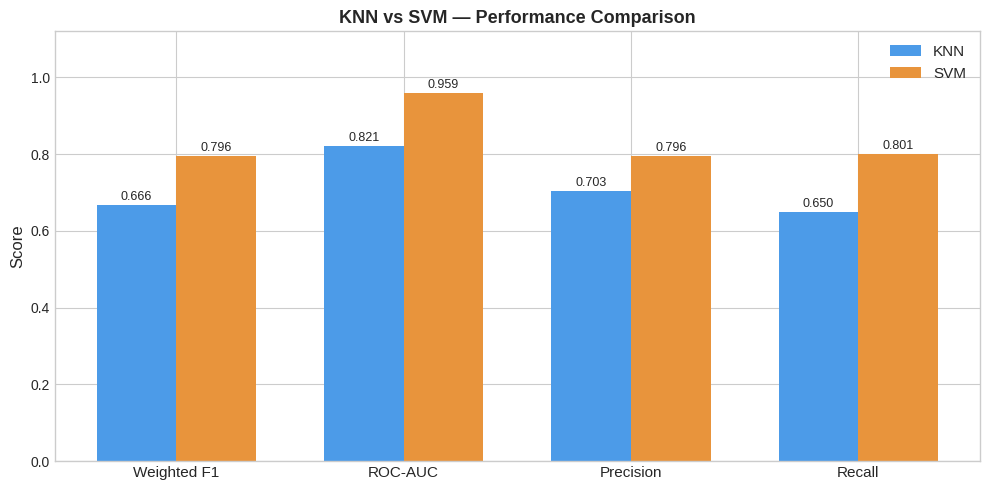

In [11]:
# Bar chart comparison
metrics    = ['Weighted F1', 'ROC-AUC', 'Precision', 'Recall']
knn_scores = comparison_df.loc['KNN'].values
svm_scores = comparison_df.loc['SVM'].values

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_knn = ax.bar(x - width/2, knn_scores, width, label='KNN', color='#4C9BE8')
bars_svm = ax.bar(x + width/2, svm_scores, width, label='SVM', color='#E8943C')

for bar in bars_knn:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_svm:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_title('KNN vs SVM — Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

Both ROC curves plotted on the same axes for the largest class (Proximal Tubule). This gives a direct visual comparison of how well each model separates that class from all others across all probability thresholds.

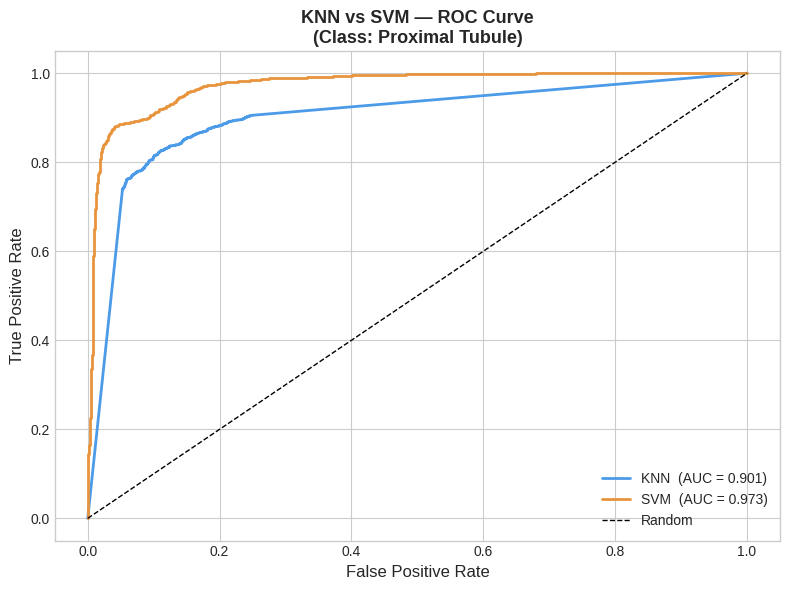

In [12]:
# Overlaid ROC curves for the largest class
largest_class     = pd.Series(y_test.values).value_counts().index[0]
largest_class_idx = classes.index(largest_class)

# Assert that predict_proba column order matches `classes` for both models.
# sklearn sets .classes_ to sorted(unique(y_train)), same as our `classes` list,
# but we check explicitly so any mismatch raises an error instead of silently
# picking the wrong probability column.
assert list(np.asarray(knn_compare.classes_)) == classes, (
    f'KNN class order does not match `classes`. '
    f'KNN: {list(knn_compare.classes_)}, expected: {classes}'
)
assert list(best_svm.classes_) == classes, (
    f'SVM class order does not match `classes`. '
    f'SVM: {list(best_svm.classes_)}, expected: {classes}'
)

fpr_knn, tpr_knn, _ = roc_curve(y_test_bin[:, largest_class_idx], y_prob_knn[:, largest_class_idx])
fpr_svm, tpr_svm, _ = roc_curve(y_test_bin[:, largest_class_idx], y_prob[:, largest_class_idx])

auc_knn = auc(fpr_knn, tpr_knn)
auc_svm = auc(fpr_svm, tpr_svm)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_knn, tpr_knn, color='#4C9BE8', linewidth=2, label=f'KNN  (AUC = {auc_knn:.3f})')
ax.plot(fpr_svm, tpr_svm, color='#E8943C', linewidth=2, label=f'SVM  (AUC = {auc_svm:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
ax.set_title(f'KNN vs SVM — ROC Curve\n(Class: {largest_class})', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 12. Summary

Final results for SVM and the head-to-head comparison with KNN. This cell prints the best SVM hyperparameters, all four evaluation metrics for both models, and declares the winner by Weighted F1.

---

## How to Improve SVM Further

The tuned SVM scores **Weighted F1 = 0.5350** and **AUC = 0.8626**. It outperforms KNN on AUC and Precision, but lags on F1 and Recall. The same four tubule subtypes that hurt KNN (Distal Convoluted Tubule F1=0.17, Loop of Henle F1=0.18, Ascending Thin Limb F1=0.16, Thick Ascending Limb F1=0.24) remain the primary weakness. Here are concrete ways to improve:

**1. Increase the number of selected features**
Re-run Notebook 2 with more genes (e.g. 30, 50, or 100). SVM with an RBF kernel can exploit a richer feature space effectively -- more genes means more dimensions for the kernel to find non-linear boundaries between the overlapping tubule subtypes.

**2. Apply SMOTE**
Enable the SMOTE block in Notebook 2. The current training set is imbalanced (Proximal Tubule ~49%), which causes the SVM's `class_weight='balanced'` to over-correct for some minority classes (notably Endothelium). SMOTE provides a more natural balance and may reduce the over-prediction problem.

**3. Increase Bayesian search trials**
Increase `n_iter` from 20 to 50 or more. The current best (C=2.94, gamma=0.126) was found from only 20 trials -- more trials give the Bayesian optimiser more time to converge on a better region of the search space.

**4. Try a linear kernel with a wider C range**
With only 17 features, a linear kernel may outperform RBF. Expand the search to include `C` values up to 1,000 on a log scale and force `kernel='linear'` to test this directly.

**5. Use all 20,000 cells**
This run used a 10,000-cell sample. Doubling to 20,000 gives the SVM more support vectors for rare classes, which improves its ability to define tight margins around small populations like Distal Convoluted Tubule.

In [13]:
winner = comparison_df['Weighted F1'].idxmax()

print('NOTEBOOK 4 — SVM — FINAL RESULTS')
print()
print('Best SVM hyperparameters:')
for param, value in bayes_search.best_params_.items():
    print(f'  {param:<10}: {value}')
print()
print(f'Baseline Weighted F1  : {base_f1:.4f}')
print(f'Tuned    Weighted F1  : {tuned_f1:.4f}')
print(f'Baseline ROC-AUC      : {base_roc_auc:.4f}')
print(f'Tuned    ROC-AUC      : {tuned_roc_auc:.4f}')
print()
print('Final model comparison:')
print()
print(comparison_df.to_string())
print()
print(f'Best model by Weighted F1 : {winner}')
print()
print('Pipeline complete.')

NOTEBOOK 4 — SVM — FINAL RESULTS

Best SVM hyperparameters:
  C         : 100.0
  gamma     : 0.001915573264169931

Baseline Weighted F1  : 0.7958
Tuned    Weighted F1  : 0.7964
Baseline ROC-AUC      : 0.9641
Tuned    ROC-AUC      : 0.9588

Final model comparison:

     Weighted F1  ROC-AUC  Precision  Recall
KNN       0.6664   0.8210     0.7031  0.6505
SVM       0.7964   0.9588     0.7956  0.8010

Best model by Weighted F1 : SVM

Pipeline complete.
